In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("data/project_data_clean.csv")
df['date'] = pd.to_datetime(df['date'])
df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['year']        = df['date'].dt.year
df = pd.get_dummies(df, columns=['country'], drop_first=False)

country_cols = [c for c in df.columns if c.startswith('country_')]

# Stratified sample: 500 rows per country = 5,000 total
df_sample = (df.groupby(df[country_cols].idxmax(axis=1), group_keys=False)
               .apply(lambda g: g.sample(min(500, len(g)), random_state=42))
               .reset_index(drop=True))

print(f"Full dataset : {len(df):,} rows")
print(f"SVR sample   : {len(df_sample):,} rows")

Full dataset : 18,270 rows
SVR sample   : 5,000 rows


In [4]:
# 2. FEATURE SETS
# ─────────────────────────────────────────────
CO2_FEATURES = [
    'avg_temp_degrees_celsius', 'humidity_percentage',
    'energy_consumption_MWh_per_day', 'renewable_share_percentage',
    'urban_population_percentage', 'industrial_activity_index',
    'energy_price_euros_per_MWh', 'month', 'day_of_year', 'year'
] + country_cols

TEMP_FEATURES = [
    'co2_emission_tons_per_day', 'humidity_percentage',
    'energy_consumption_MWh_per_day', 'renewable_share_percentage',
    'urban_population_percentage', 'industrial_activity_index',
    'energy_price_euros_per_MWh', 'month', 'day_of_year', 'year'
] + country_cols


In [5]:
# 3. HELPER FUNCTIONS
# ─────────────────────────────────────────────
def prepare_data(data, features, target, test_size=0.2, random_state=42):
    X = data[features].values
    y = data[target].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state)
    sx = StandardScaler(); sy = StandardScaler()
    X_tr   = sx.fit_transform(X_tr);  X_te  = sx.transform(X_te)
    y_tr_s = sy.fit_transform(y_tr.reshape(-1,1)).ravel()
    return X_tr, X_te, y_tr_s, y_tr, y_te, sy

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*48}\n  SVR Results — {label}\n{'='*48}")
    print(f"  MAE  : {mae:.4f}\n  RMSE : {rmse:.4f}\n  R²   : {r2:.4f}")
    return mae, rmse, r2

def plot_results(y_true, y_pred, label, unit, filename, n=200):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(y_true[:n], label='Actual',    color='steelblue', linewidth=1.2)
    axes[0].plot(y_pred[:n], label='Predicted', color='darkorange',
                 linewidth=1.2, linestyle='--', alpha=0.85)
    axes[0].set_title(f'SVR: Actual vs Predicted — {label} (first {n} test samples)',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Sample Index'); axes[0].set_ylabel(unit)
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].scatter(y_true, y_pred, alpha=0.4, s=12, color='teal')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    axes[1].set_title(f'SVR: Predicted vs Actual Scatter — {label}',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel(f'Actual {unit}'); axes[1].set_ylabel(f'Predicted {unit}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150); plt.show()
    print(f"  Saved: {filename}")


  TASK 1: SVR — CO2 Emissions
Training SVR for CO2...

  SVR Results — CO2 Emissions (tons/day)
  MAE  : 234.5770
  RMSE : 294.3906
  R²   : -0.6298


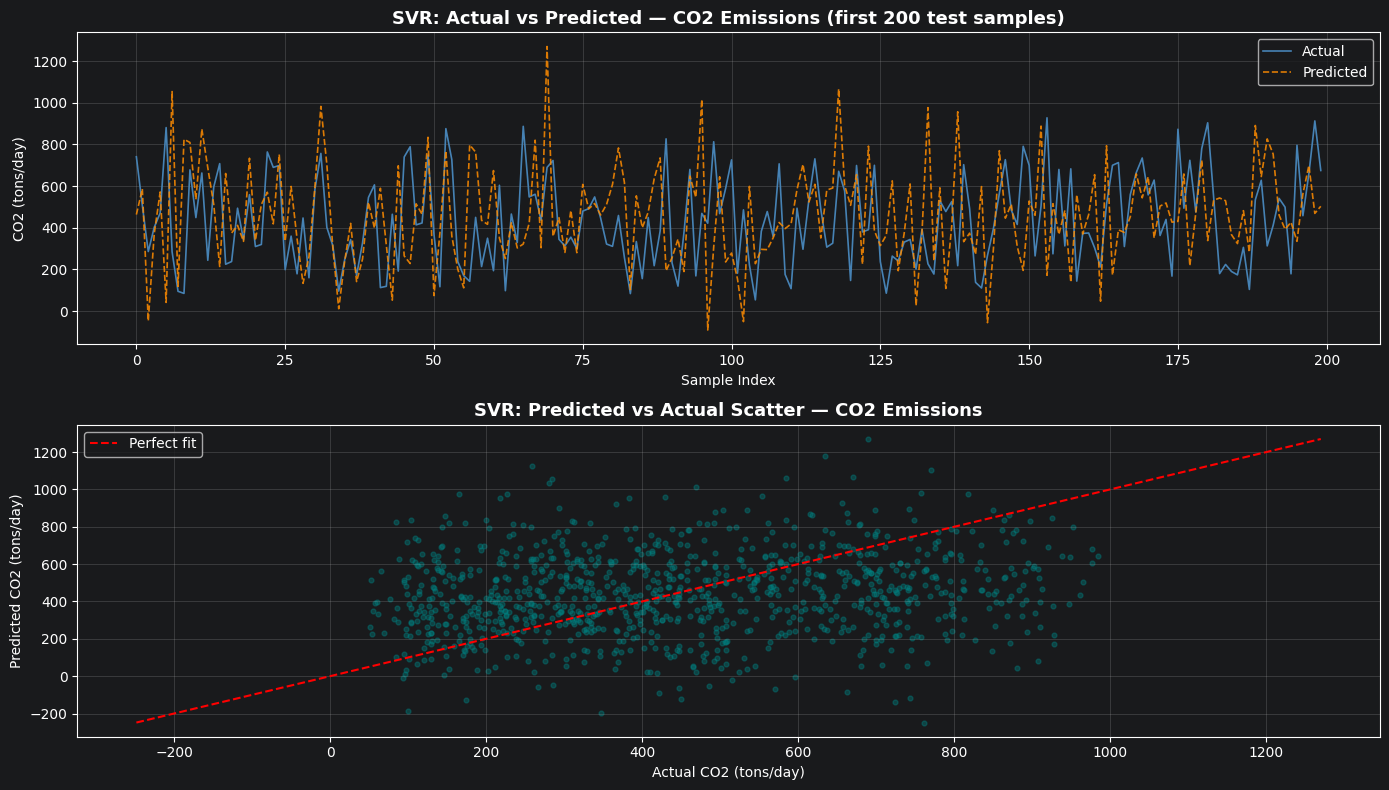

  Saved: SVR_CO2_Results.png


In [6]:
# 4. SVR — CO2 EMISSIONS
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("  TASK 1: SVR — CO2 Emissions")
print("="*50)

X_tr, X_te, y_tr_s, y_tr, y_te, sy = prepare_data(
    df_sample, CO2_FEATURES, 'co2_emission_tons_per_day')

svr_co2 = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
print("Training SVR for CO2...")
svr_co2.fit(X_tr, y_tr_s)
y_pred_co2 = sy.inverse_transform(svr_co2.predict(X_te).reshape(-1,1)).ravel()
mae_co2, rmse_co2, r2_co2 = evaluate(y_te, y_pred_co2, "CO2 Emissions (tons/day)")
plot_results(y_te, y_pred_co2, "CO2 Emissions", "CO2 (tons/day)", "SVR_CO2_Results.png")



  TASK 2: SVR — Average Temperature
Training SVR for Temperature...

  SVR Results — Average Temperature (°C)
  MAE  : 1.8398
  RMSE : 2.3329
  R²   : 0.9476


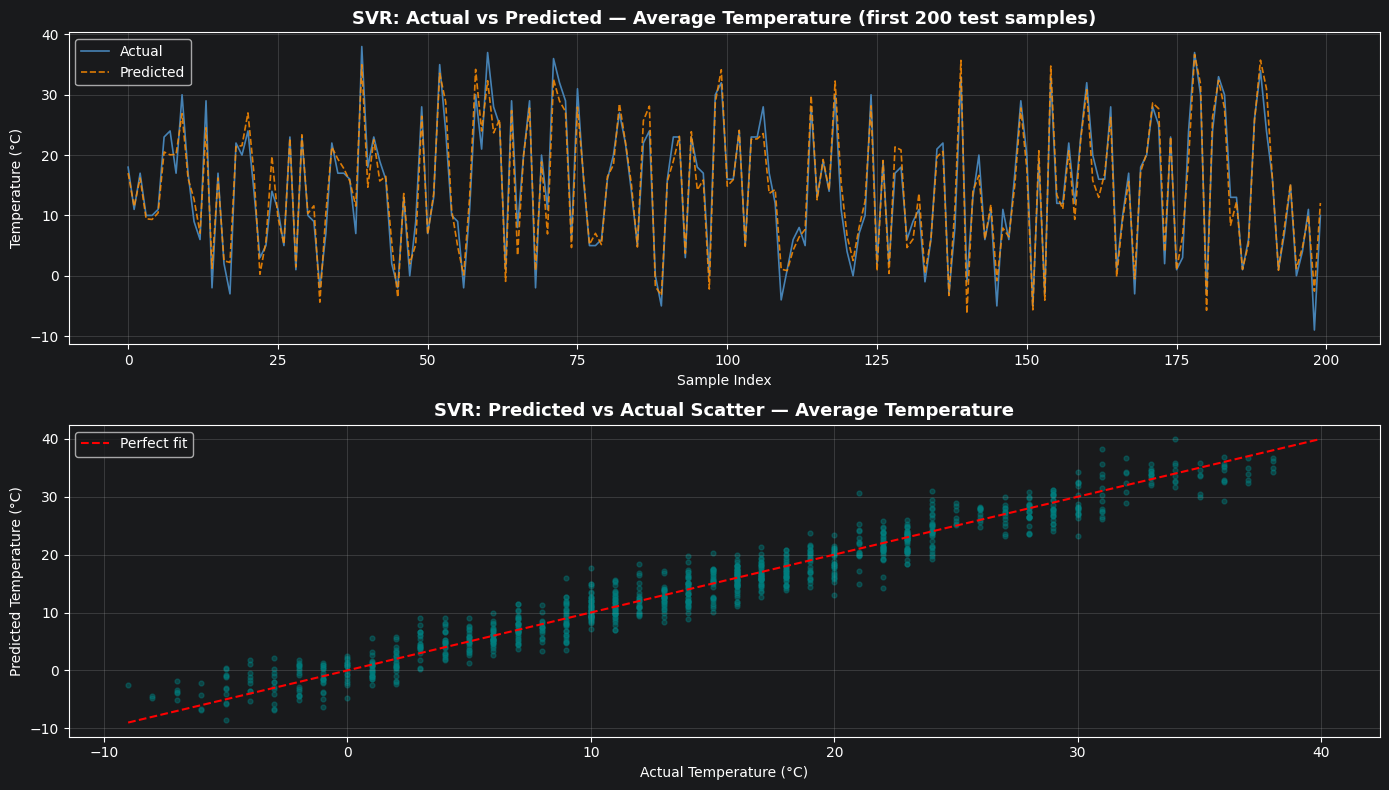

  Saved: SVR_Temperature_Results.png


In [7]:
# 5. SVR — TEMPERATURE
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("  TASK 2: SVR — Average Temperature")
print("="*50)

X_tr, X_te, y_tr_s, y_tr, y_te, sy = prepare_data(
    df_sample, TEMP_FEATURES, 'avg_temp_degrees_celsius')

svr_tmp = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
print("Training SVR for Temperature...")
svr_tmp.fit(X_tr, y_tr_s)
y_pred_tmp = sy.inverse_transform(svr_tmp.predict(X_te).reshape(-1,1)).ravel()
mae_tmp, rmse_tmp, r2_tmp = evaluate(y_te, y_pred_tmp, "Average Temperature (°C)")
plot_results(y_te, y_pred_tmp, "Average Temperature", "Temperature (°C)", "SVR_Temperature_Results.png")

In [8]:
# 6. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  SVR SUMMARY TABLE")
print("="*55)
summary = pd.DataFrame({
    'Target'  : ['CO2 Emissions (tons/day)', 'Avg Temperature (°C)'],
    'MAE'     : [round(mae_co2,4),  round(mae_tmp,4)],
    'RMSE'    : [round(rmse_co2,4), round(rmse_tmp,4)],
    'R²'      : [round(r2_co2,4),   round(r2_tmp,4)],
    'Kernel'  : ['RBF', 'RBF'],
    'C'       : [100, 100],
    'Epsilon' : [0.1, 0.1],
})
print(summary.to_string(index=False))
summary.to_csv("SVR_Summary_Metrics.csv", index=False)
print("\nSaved: SVR_Summary_Metrics.csv")


  SVR SUMMARY TABLE
                  Target      MAE     RMSE      R² Kernel   C  Epsilon
CO2 Emissions (tons/day) 234.5770 294.3906 -0.6298    RBF 100      0.1
    Avg Temperature (°C)   1.8398   2.3329  0.9476    RBF 100      0.1

Saved: SVR_Summary_Metrics.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# 1. LOAD & PREPARE DATA
# ─────────────────────────────────────────────
df = pd.read_csv("C:/Users/Gargi Adsul/Downloads/project_data_clean (1).csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['country', 'date']).reset_index(drop=True)

df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['year']        = df['date'].dt.year
df = pd.get_dummies(df, columns=['country'], drop_first=False)

country_cols = [c for c in df.columns if c.startswith('country_')]

In [4]:
# 2. FEATURE SETS
# ─────────────────────────────────────────────
CO2_FEATURES = [
    'avg_temp_degrees_celsius', 'humidity_percentage',
    'energy_consumption_MWh_per_day', 'renewable_share_percentage',
    'urban_population_percentage', 'industrial_activity_index',
    'energy_price_euros_per_MWh', 'month', 'day_of_year', 'year'
] + country_cols

TEMP_FEATURES = [
    'co2_emission_tons_per_day', 'humidity_percentage',
    'energy_consumption_MWh_per_day', 'renewable_share_percentage',
    'urban_population_percentage', 'industrial_activity_index',
    'energy_price_euros_per_MWh', 'month', 'day_of_year', 'year'
] + country_cols


In [5]:
# 3. SLIDING WINDOW
# ─────────────────────────────────────────────
LOOKBACK = 30   # 30-day history window

def create_sequences(X, y, lookback=LOOKBACK):
    """
    Converts flat arrays into overlapping sequences.
    Each sample: lookback days of features → predict next day value.
    Output X shape: (n_samples, lookback, n_features)
    """
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

In [6]:
# 4. CNN ARCHITECTURE
# ─────────────────────────────────────────────
def build_cnn(input_shape):
    """
    1D CNN for time-series regression.

    Architecture:
      Block 1: Conv1D(64, k=3) → BatchNorm → MaxPool(2)
      Block 2: Conv1D(128, k=3) → BatchNorm → MaxPool(2)
      Block 3: Conv1D(64, k=3) → BatchNorm
      Head:    Flatten → Dense(128) → Dropout(0.3)
                       → Dense(64)  → Dropout(0.2)
                       → Dense(1)   [regression output]
    """
    model = Sequential([
        Conv1D(64,  kernel_size=3, activation='relu',
               padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(64,  kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64,  activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

In [7]:
# 5. TRAIN & EVALUATE FUNCTION
# ─────────────────────────────────────────────
def run_cnn(df, features, target, label, unit, fig_prefix):
    print(f"\n{'='*55}")
    print(f"  1D CNN — Predicting {label}")
    print(f"{'='*55}")

    # Scale
    sx = StandardScaler(); sy = StandardScaler()
    X_s = sx.fit_transform(df[features].values)
    y_s = sy.fit_transform(df[target].values.reshape(-1,1)).ravel()

    # Sequences
    X_seq, y_seq = create_sequences(X_s, y_s, LOOKBACK)
    print(f"  Sequence shape : {X_seq.shape}")

    # Temporal split (no shuffle — preserves time order)
    split    = int(len(X_seq) * 0.8)
    X_tr, X_te = X_seq[:split], X_seq[split:]
    y_tr, y_te = y_seq[:split], y_seq[split:]
    print(f"  Train : {len(X_tr):,}   Test : {len(X_te):,}")

    # Build
    model = build_cnn(input_shape=(LOOKBACK, X_seq.shape[2]))
    model.summary()

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ]

    # Train
    history = model.fit(
        X_tr, y_tr,
        epochs=100, batch_size=64,
        validation_split=0.1,
        callbacks=callbacks, verbose=1
    )

    # Predict & inverse transform
    y_pred = sy.inverse_transform(model.predict(X_te).reshape(-1,1)).ravel()
    y_true = sy.inverse_transform(y_te.reshape(-1,1)).ravel()

    # Metrics
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

    # ── Figure 1: Training curves ──
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'1D CNN Loss — {label}', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['mae'],     label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')
    ax2.set_title(f'1D CNN MAE — {label}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{fig_prefix}_Training_History.png", dpi=150)
    plt.show()

    # ── Figure 2: Actual vs Predicted ──
    n = 300
    fig2, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(y_true[:n], label='Actual',    color='steelblue', linewidth=1.2)
    axes[0].plot(y_pred[:n], label='Predicted', color='darkorange',
                 linewidth=1.2, linestyle='--', alpha=0.85)
    axes[0].set_title(f'1D CNN: Actual vs Predicted — {label} (first {n} samples)',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Sample Index'); axes[0].set_ylabel(unit)
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].scatter(y_true, y_pred, alpha=0.3, s=8, color='teal')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    axes[1].set_title(f'1D CNN: Scatter — {label}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(f'Actual {unit}'); axes[1].set_ylabel(f'Predicted {unit}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{fig_prefix}_Predictions.png", dpi=150)
    plt.show()

    print(f"  Saved: {fig_prefix}_Training_History.png")
    print(f"  Saved: {fig_prefix}_Predictions.png")
    return mae, rmse, r2


  1D CNN — Predicting CO2 Emissions
  Sequence shape : (18240, 30, 20)
  Train : 14,592   Test : 3,648


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,065 (469.00 KB)

 Trainable params: 119,553 (467.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 1.1183 - mae: 0.8770 - val_loss: 0.9261 - val_mae: 0.8092 - learning_rate: 0.0010
Epoch 2/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.9329 - mae: 0.8113 - val_loss: 0.9095 - val_mae: 0.7999 - learning_rate: 0.0010
Epoch 3/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.9053 - mae: 0.8006 - val_loss: 0.8884 - val_mae: 0.7938 - learning_rate: 0.0010
Epoch 4/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.8874 - mae: 0.7943 - val_loss: 0.8824 - val_mae: 0.7899 - learning_rate: 0.0010
Epoch 5/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.8750 - mae: 0.7891 - val_loss: 0.8710 - val_mae: 0.7845 - learning_rate: 0.0010
Epoch 6/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.8625 - mae: 0.7829 - val_loss: 0.8871 - val_mae: 0.7917 - learning_rate: 0.0010
Epoch 7/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.8471 - mae: 0.7749 - val_loss: 0.8844 - val_mae: 0.7911 - learning_rate:

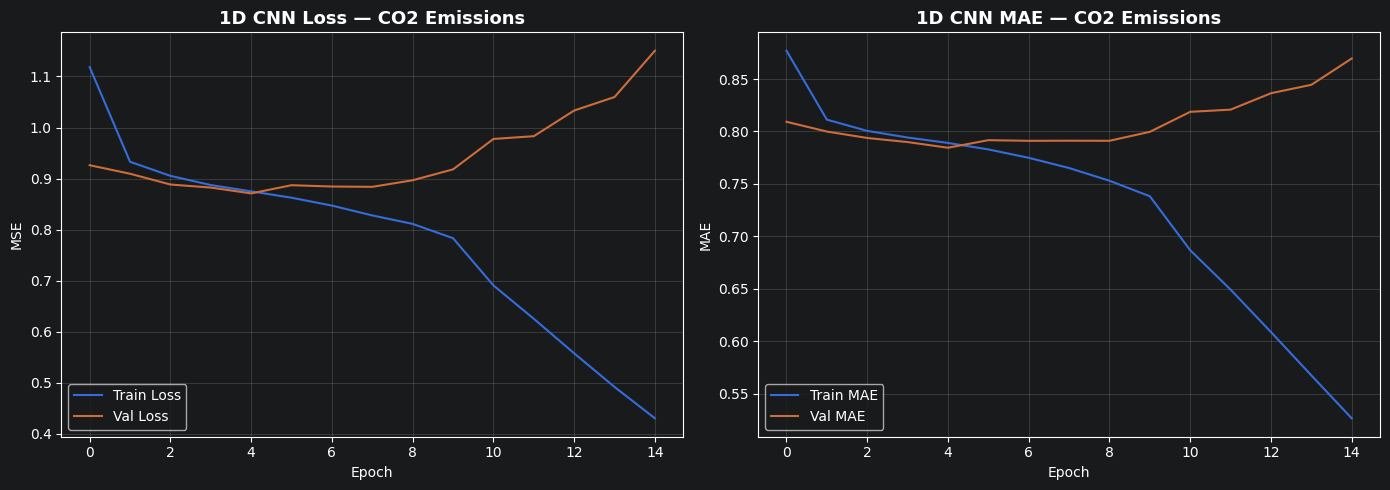

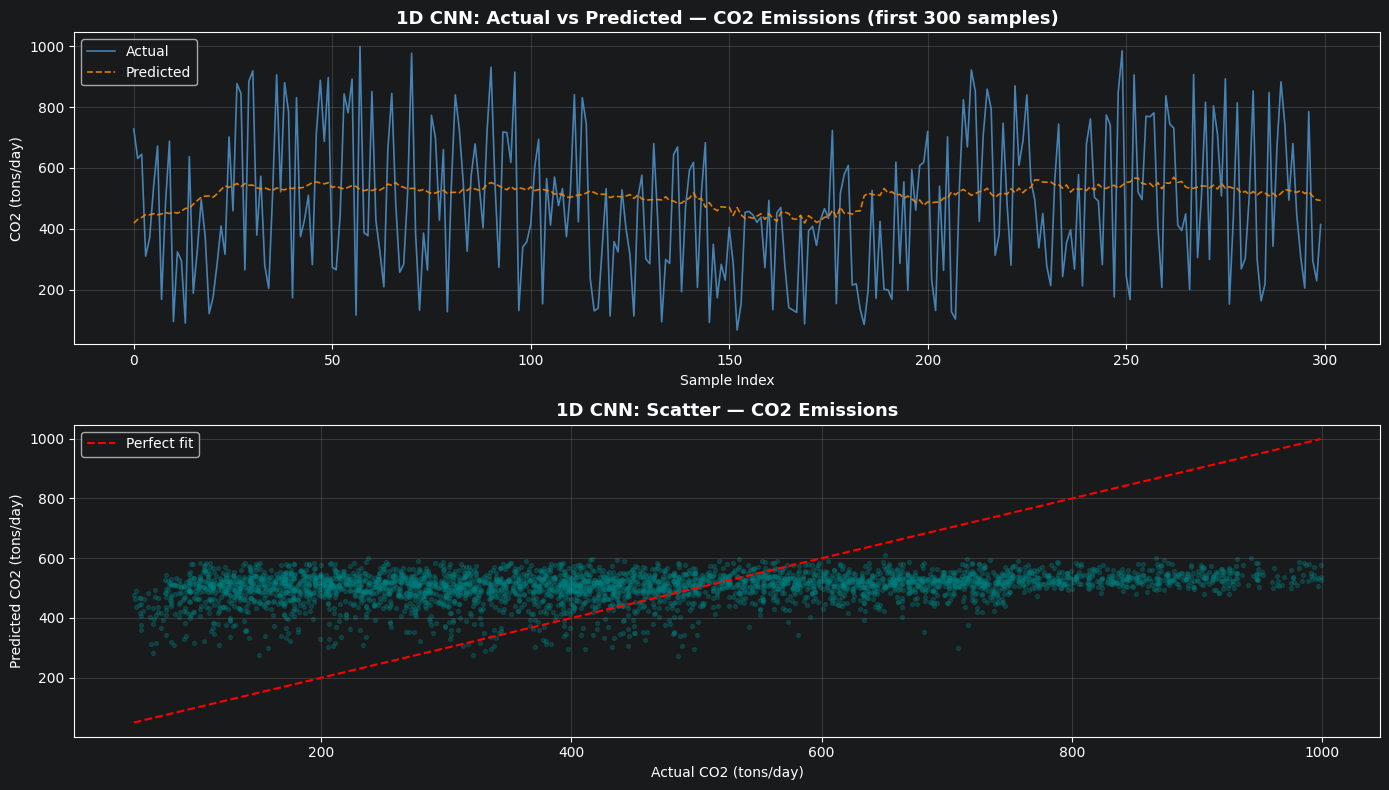

  Saved: CNN_CO2_Training_History.png
  Saved: CNN_CO2_Predictions.png

  1D CNN — Predicting Average Temperature
  Sequence shape : (18240, 30, 20)
  Train : 14,592   Test : 3,648


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 30, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 7, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,065 (469.00 KB)

 Trainable params: 119,553 (467.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.3575 - mae: 0.4511 - val_loss: 0.3916 - val_mae: 0.5216 - learning_rate: 0.0010
Epoch 2/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1361 - mae: 0.2903 - val_loss: 0.2557 - val_mae: 0.4261 - learning_rate: 0.0010
Epoch 3/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1094 - mae: 0.2602 - val_loss: 0.1351 - val_mae: 0.2964 - learning_rate: 0.0010
Epoch 4/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0950 - mae: 0.2428 - val_loss: 0.1999 - val_mae: 0.3694 - learning_rate: 0.0010
Epoch 5/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0850 - mae: 0.2299 - val_loss: 0.1805 - val_mae: 0.3518 - learning_rate: 0.0010
Epoch 6/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0830 - mae: 0.2262 - val_loss: 0.1625 - val_mae: 0.3297 - learning_rate: 0.0010
Epoch 7/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0754 - mae: 0.2167 - val_loss: 0.1951 - val_mae: 0.3645 - learning_rate:

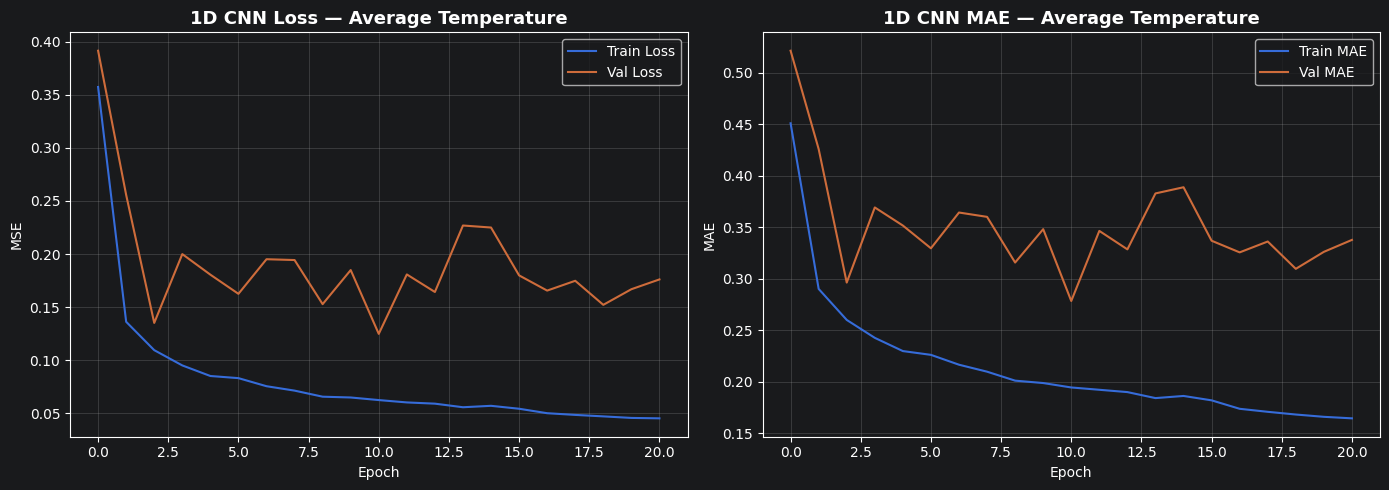

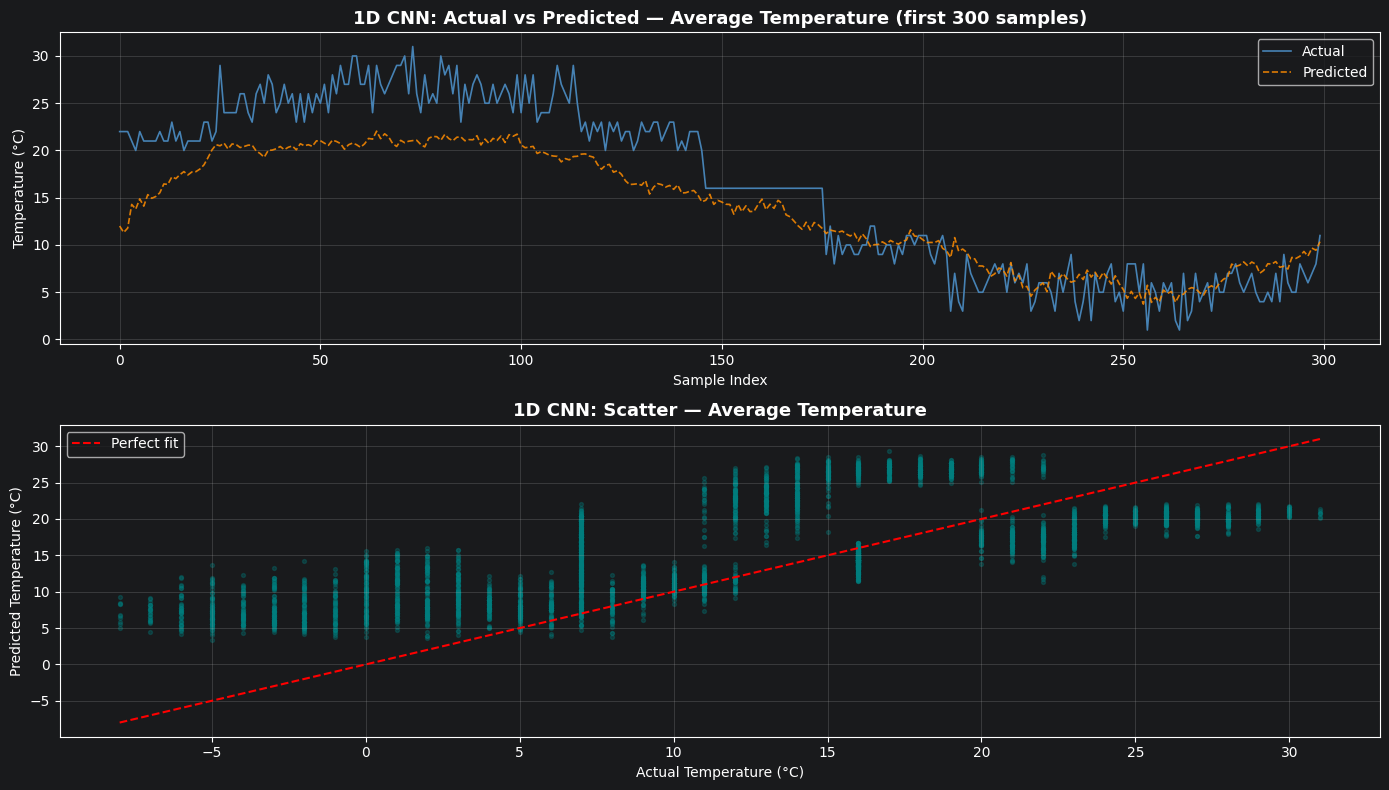

  Saved: CNN_Temperature_Training_History.png
  Saved: CNN_Temperature_Predictions.png


In [8]:
# 6. RUN BOTH MODELS
# ─────────────────────────────────────────────
mae_co2,  rmse_co2,  r2_co2  = run_cnn(
    df, CO2_FEATURES,  'co2_emission_tons_per_day',
    'CO2 Emissions',      'CO2 (tons/day)',      'CNN_CO2')

mae_temp, rmse_temp, r2_temp = run_cnn(
    df, TEMP_FEATURES, 'avg_temp_degrees_celsius',
    'Average Temperature', 'Temperature (°C)',   'CNN_Temperature')

In [9]:
# 7. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  1D CNN SUMMARY TABLE")
print("="*55)
summary = pd.DataFrame({
    'Target'   : ['CO2 Emissions (tons/day)', 'Avg Temperature (°C)'],
    'MAE'      : [round(mae_co2,4),  round(mae_temp,4)],
    'RMSE'     : [round(rmse_co2,4), round(rmse_temp,4)],
    'R²'       : [round(r2_co2,4),   round(r2_temp,4)],
    'Lookback' : [LOOKBACK, LOOKBACK],
    'Epochs'   : ['EarlyStopping', 'EarlyStopping']
})
print(summary.to_string(index=False))
summary.to_csv("CNN_Summary_Metrics.csv", index=False)
print("\nSaved: CNN_Summary_Metrics.csv")


  1D CNN SUMMARY TABLE
                  Target      MAE     RMSE     R²  Lookback        Epochs
CO2 Emissions (tons/day) 199.5968 234.1286 0.0162        30 EarlyStopping
    Avg Temperature (°C)   6.5881   7.7226 0.3203        30 EarlyStopping

Saved: CNN_Summary_Metrics.csv
